In [315]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [37]:
x_train=pd.read_csv("C:\\Users\\erike\\OneDrive//Python-Class//x_train_p.csv")
x_test=pd.read_csv("C:\\Users\\erike\\OneDrive//Python-Class//x_test_p.csv")
y_train=pd.read_csv("C:\\Users\\erike\\OneDrive//Python-Class//y_train_p.csv")
y_test=pd.read_csv("C:\\Users\\erike\\OneDrive//Python-Class//y_test_p.csv")
train_df=pd.read_csv("C:\\Users\\erike\\OneDrive//Python-Class//x_train_p.csv")
test_df=pd.read_csv("C:\\Users\\erike\\OneDrive//Python-Class//x_test_p.csv")
df=pd.read_csv("C:\\Users\\erike\\OneDrive//Python-Class//pulsar_stars.csv")

In [16]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((12528, 5), (5370, 5), (12528, 1), (5370, 1))

In [295]:
y_test = np.asarray(y_test).ravel()
y_train = np.asarray(y_train).ravel()

In [305]:
model = DecisionTreeClassifier(random_state=518, max_leaf_nodes=3)
model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",518
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [306]:
y_predt = model.predict(x_test)

In [307]:
print (accuracy_score(y_test,y_predt))

0.9767225325884544


In [308]:
print (recall_score(y_test, y_predt))

0.8244575936883629


In [309]:
print(precision_score(y_test, y_predt))

0.920704845814978


In [316]:
print(roc_auc_score(y_test, y_predt))

0.9085273779669452


In [310]:
print(confusion_matrix(y_test, y_predt))

[[4827   36]
 [  89  418]]


In [311]:
print(classification_report(y_test, y_predt))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4863
           1       0.92      0.82      0.87       507

    accuracy                           0.98      5370
   macro avg       0.95      0.91      0.93      5370
weighted avg       0.98      0.98      0.98      5370



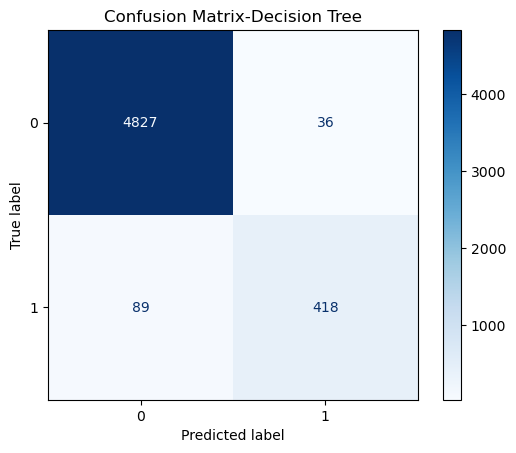

In [312]:
cm = confusion_matrix(y_test, y_predt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix-Decision Tree")
plt.show()

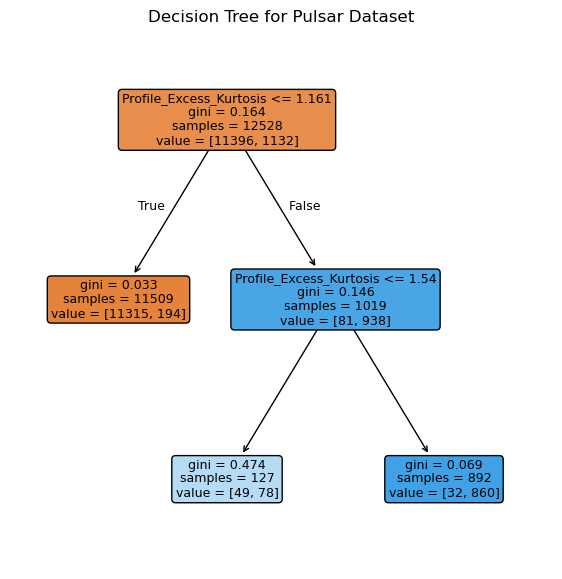

In [313]:
plt.figure(figsize=(7, 7))
plot_tree(model, filled=True, rounded=True, feature_names=x_train.columns)
plt.title("Decision Tree for Pulsar Dataset")
plt.show()

In [10]:
params = {
         "max_depth": [12,15,21,30,40],
         "max_features":[0.1,0.2,0.3,0.4],
         "min_samples_split":[2,4,6,8],
         "criterion": ['gini', 'entropy']
         }
model=GridSearchCV(estimator = DecisionTreeClassifier(random_state=518, max_leaf_nodes=3), param_grid=params, cv=4)
model.fit(x_train,y_train)
no_of_combinations = 1
for key, value in params.items():
    no_of_combinations *= len(value)
print("best params: ", model.best_params_)
print("best score: ", model.best_score_)

best params:  {'criterion': 'gini', 'max_depth': 12, 'max_features': 0.4, 'min_samples_split': 2}
best score:  0.9778895274584929


In [415]:
model = DecisionTreeClassifier(max_depth=12, max_features=0.4, min_samples_split=2, criterion='gini', random_state=518, max_leaf_nodes=3)
model.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",0.4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",518
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node

In [421]:
y_pred2 = model.predict(x_test)

In [419]:
print (accuracy_score(y_test,y_predt2))

0.9733705772811918


In [424]:
print (recall_score(y_test, y_predt2))

0.7751479289940828


In [425]:
print(precision_score(y_test, y_predt2))

0.9312796208530806


In [426]:
print(roc_auc_score(y_test, y_predt2))

0.8845922659570455


In [323]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predt2))

Confusion Matrix:
 [[4834   29]
 [ 114  393]]


In [423]:
print("\nClassification Report:\n", classification_report(y_test, y_predt2))


Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      4863
           1       0.93      0.78      0.85       507

    accuracy                           0.97      5370
   macro avg       0.95      0.88      0.92      5370
weighted avg       0.97      0.97      0.97      5370



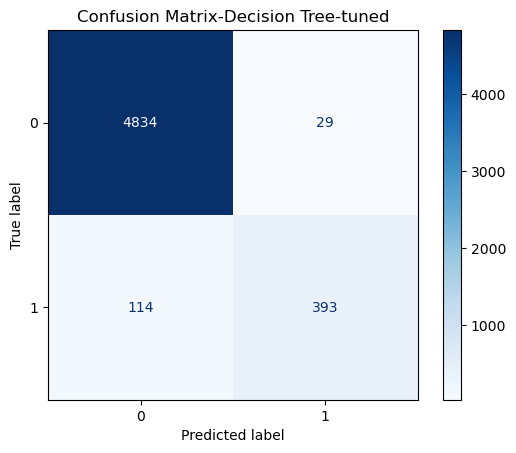

In [422]:
cm = confusion_matrix(y_test, y_pred2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix-Decision Tree-tuned")
plt.show()

In [326]:
rf = RandomForestClassifier(random_state=518)

In [327]:
rf.fit(x_train, y_train) #in spite of error it does work

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [328]:
y_predrf = rf.predict(x_test)

In [329]:
print (accuracy_score(y_test,y_predrf))

0.9782122905027933


In [330]:
print (precision_score(y_test,y_predrf))

0.9202586206896551


In [331]:
print (recall_score(y_test,y_predrf))

0.8422090729783037


In [332]:
print (roc_auc_score(y_test,y_predrf))

0.9173003004208813


In [358]:
print (classification_report(y_test,y_predrf))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4863
           1       0.92      0.84      0.88       507

    accuracy                           0.98      5370
   macro avg       0.95      0.92      0.93      5370
weighted avg       0.98      0.98      0.98      5370



In [333]:
cm = confusion_matrix(y_test, y_predrf)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[4826   37]
 [  80  427]]


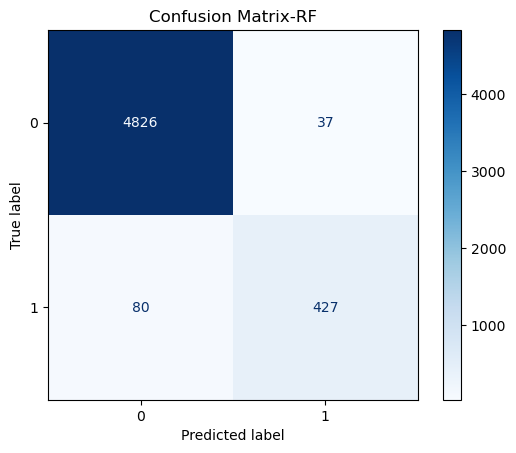

In [334]:
cm = confusion_matrix(y_test, y_predrf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix-RF")
plt.show()

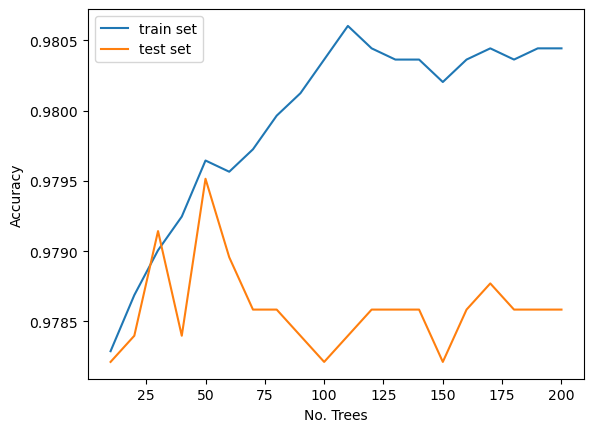

Best Test Score:  0.9795158286778398
Optimal Trees Test:  50
Best Train Score:  0.9806034482758621
Optimal Train Trees:  110


In [42]:
train_scores = []
test_scores = []
for trees in range(10,201,10):
    rf=RandomForestClassifier(n_estimators=trees, n_jobs=-1, random_state=518)
    train_scores.append(cross_val_score(rf,x_train,y_train,cv=4).mean())
    rf.fit(x_train, y_train)
    test_scores.append(rf.score(x_test,y_test))
plt.plot(range(10,201,10),train_scores,label="train set")
plt.plot(range(10,201,10),test_scores, label="test set")
plt.xlabel("No. Trees")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
print("Best Test Score: ", max(test_scores))
print("Optimal Trees Test: ", (np.array(test_scores).argmax()*10+10))
print("Best Train Score: ", max(train_scores))
print("Optimal Train Trees: ", (np.array(train_scores).argmax()*10+10))

In [43]:
params = {"n_estimators": [50,80,100,150,190],
         "max_depth": [12,15,21,30,40],
         "max_features":[0.1,0.2,0.3,0.4],
         "min_samples_split":[2,4,6,8],
         "class_weight": [None,"balanced"]
         }
model=GridSearchCV(RandomForestClassifier(n_jobs=-1, random_state=518), params, cv=4)
model.fit(x_train,y_train)
no_of_combinations = 1
for key, value in params.items():
    no_of_combinations *= len(value)
print("best params: ", model.best_params_)
print("best score: ", model.best_score_)

best params:  {'class_weight': None, 'max_depth': 30, 'max_features': 0.4, 'min_samples_split': 4, 'n_estimators': 50}
best score:  0.9810025542784163


In [335]:
rf = RandomForestClassifier(n_estimators=50, max_depth=30, min_samples_split=4, max_features=0.4, class_weight=None, random_state=518)

In [336]:
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.4
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tru

In [427]:
y_predrf2 = rf.predict(x_test)

In [428]:
print(accuracy_score(y_test, y_predrf2))

0.9789571694599628


In [429]:
print(recall_score(y_test, y_predrf2))

0.8461538461538461


In [342]:
print(precision_score(y_test, y_predrf2))

0.9245689655172413


In [343]:
print(roc_auc_score(y_test, y_predrf2))

0.9194783213907213


In [357]:
print(classification_report(y_test, y_predrf2))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4863
           1       0.92      0.85      0.88       507

    accuracy                           0.98      5370
   macro avg       0.95      0.92      0.94      5370
weighted avg       0.98      0.98      0.98      5370



In [344]:
cm = confusion_matrix(y_test, y_predrf2)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[4828   35]
 [  78  429]]


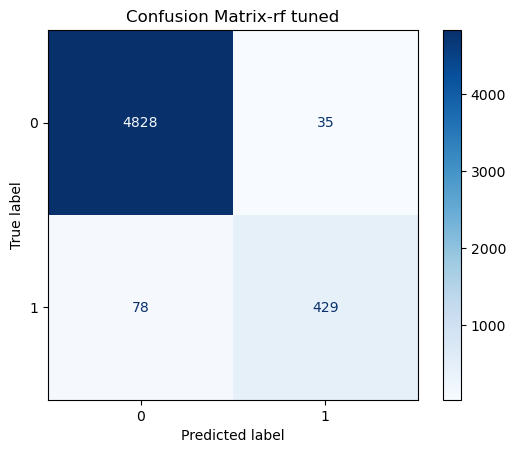

In [430]:
cm = confusion_matrix(y_test, y_predrf2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix-rf tuned")
plt.show()

In [ ]:
#The Grid Search Values do not appear to do significantly better.

In [345]:
modellog=LogisticRegression(random_state=518)
modellog.fit(x_train, y_train)
y_predlog=model.predict(x_test)
y_pred_problog=model.predict_proba(x_test)

In [351]:
print(accuracy_score(y_test,y_predlog))

0.9733705772811918


In [352]:
print(recall_score(y_test,y_predlog))

0.7751479289940828


In [353]:
print(precision_score(y_test,y_predlog))

0.9312796208530806


In [354]:
print(roc_auc_score(y_test,y_predlog))

0.8845922659570455


In [64]:
print(classification_report(y_test,y_predlog))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4863
           1       0.92      0.82      0.87       507

    accuracy                           0.98      5370
   macro avg       0.95      0.91      0.93      5370
weighted avg       0.98      0.98      0.98      5370



In [355]:
print('Confusion Matrix, Logistic Regression:')
confusion_matrix(y_test, y_predlog)

Confusion Matrix, Logistic Regression:


array([[4834,   29],
       [ 114,  393]])

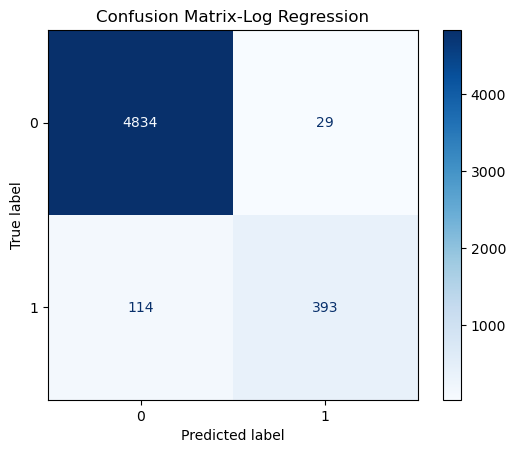

In [356]:
cm = confusion_matrix(y_test, y_predlog)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix-Log Regression")
plt.show()

In [119]:
params = {"C": [0.001, 0.01, 0.1, 1, 10, 100],
         "class_weight": [None,"balanced"],
          "solver": ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
         }
model=GridSearchCV(LogisticRegression(random_state=518), params, cv=4)
model.fit(x_train,y_train)
no_of_combinations = 1
for key, value in params.items():
    no_of_combinations *= len(value)
print("best params: ", model.best_params_)
print("best score: ", model.best_score_)

best params:  {'C': 10, 'class_weight': None, 'solver': 'newton-cg'}
best score:  0.9782886334610472


In [405]:
modellog=LogisticRegression(C=10, class_weight= None, solver='newton-cg', random_state=518)
modellog.fit(x_train, y_train)
y_predlog2=modellog.predict(x_test)
y_pred_problog=model.predict_proba(x_test)

In [406]:
print('Accuracy Score Tuned=') 
accuracy_score(y_test,y_predlog2)

Accuracy Score Tuned=


0.9778398510242086

In [407]:
print(recall_score(y_test,y_predlog2))

0.8086785009861933


In [408]:
print(precision_score(y_test,y_predlog2))

0.9490740740740741


In [409]:
print(roc_auc_score(y_test,y_predlog2))

0.9020772722903413


In [410]:
print(classification_report(y_test,y_predlog2))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      4863
           1       0.95      0.81      0.87       507

    accuracy                           0.98      5370
   macro avg       0.96      0.90      0.93      5370
weighted avg       0.98      0.98      0.98      5370



In [411]:
print('Confusion Matrix, Logistic Regression Tuned:')
confusion_matrix(y_test, y_predlog2)

Confusion Matrix, Logistic Regression Tuned:


array([[4841,   22],
       [  97,  410]])

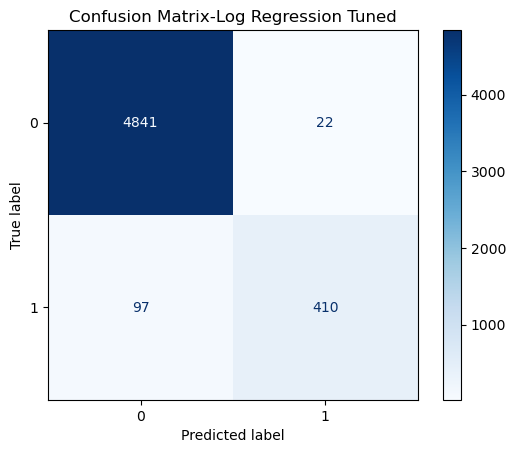

In [412]:
cm = confusion_matrix(y_test, y_predlog2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix-Log Regression Tuned")
plt.show()

In [369]:
model_ada = AdaBoostClassifier(n_estimators=100, learning_rate=2, random_state=518)
model_ada.fit(x_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",518


In [372]:
y_predada = model_ada.predict(x_test)

In [373]:
print("AdaBoost Classifier Model Accuracy:", accuracy_score(y_test, y_predada))

AdaBoost Classifier Model Accuracy: 0.03202979515828678


In [383]:
print(recall_score(y_test, y_predada))

0.14398422090729784


In [384]:
print(precision_score(y_test, y_predada))

0.01509199917304114


In [385]:
print(roc_auc_score(y_test, y_predada))

0.08217101236604865


In [386]:
print('Confusion Matrix, Adaboost:')
confusion_matrix(y_test, y_predada) 

Confusion Matrix, Adaboost:


array([[  99, 4764],
       [ 434,   73]])

In [388]:
print(classification_report(y_test, y_predada))

              precision    recall  f1-score   support

           0       0.19      0.02      0.04      4863
           1       0.02      0.14      0.03       507

    accuracy                           0.03      5370
   macro avg       0.10      0.08      0.03      5370
weighted avg       0.17      0.03      0.04      5370



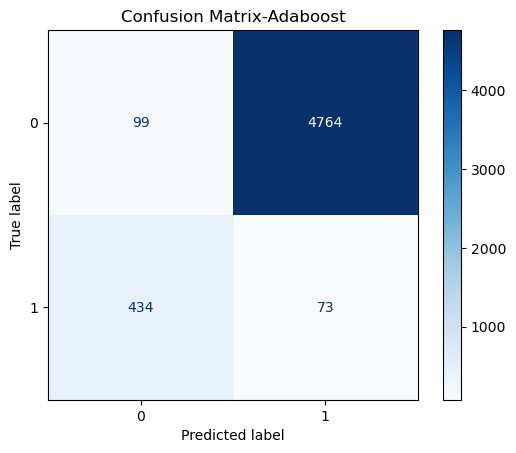

In [379]:
cm = confusion_matrix(y_test, y_predada)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix-Adaboost")
plt.show()

In [381]:
params = {"n_estimators": [1, 2, 4, 8, 16, 24, 32, 64, 100],
         "learning_rate": [0.001, 0.01, 0.1, 1, 10]
         }
model=GridSearchCV(AdaBoostClassifier(random_state=518), params, cv=4)
model.fit(x_train,y_train)
no_of_combinations = 1
for key, value in params.items():
    no_of_combinations *= len(value)
print("best params: ", model.best_params_)
print("best score: ", model.best_score_)

best params:  {'learning_rate': 0.1, 'n_estimators': 100}
best score:  0.9784482758620691


In [432]:
model_ada = AdaBoostClassifier(random_state=518, learning_rate=0.1, n_estimators=100)
model_ada.fit(x_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",518


In [433]:
ypredada2 = model_ada.predict(x_test)

In [434]:
print("AdaBoost Classifier Model Accuracy:", accuracy_score(y_test, ypredada2))

AdaBoost Classifier Model Accuracy: 0.9774674115456239


In [435]:
print(recall_score(y_test, ypredada2))

0.8185404339250493


In [397]:
print(precision_score(y_test, ypredada2))

0.9346846846846847


In [398]:
print(roc_auc_score(y_test, ypredada2))

0.9062885184225287


In [394]:
print('Confusion Matrix, Adaboost:')
confusion_matrix(y_test, ypredada2)

Confusion Matrix, Adaboost:


array([[4834,   29],
       [  92,  415]])

In [395]:
print(classification_report(y_test, ypredada2))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4863
           1       0.93      0.82      0.87       507

    accuracy                           0.98      5370
   macro avg       0.96      0.91      0.93      5370
weighted avg       0.98      0.98      0.98      5370



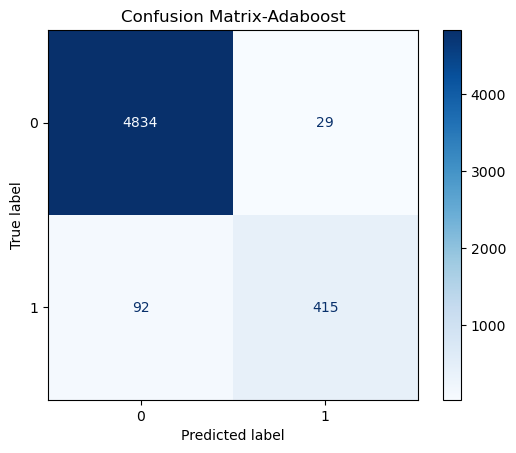

In [437]:
cm = confusion_matrix(y_test, ypredada2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix-Adaboost")
plt.show()

In [270]:
modelxg=xgb.XGBClassifier(objective='binary:logistic',random_state=518)

In [271]:
modelxg.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [272]:
ypredxg=modelxg.predict(x_test)

In [273]:
print("XGBoost Classifier Model Accuracy:", accuracy_score(y_test, ypredxg))

XGBoost Classifier Model Accuracy: 0.978584729981378


In [274]:
print(precision_score(y_test, ypredxg))

0.9279475982532751


In [275]:
print(recall_score(y_test, ypredxg))

0.8382642998027613


In [399]:
print(roc_auc_score(y_test, ypredxg))

0.9157391825972475


In [219]:
print(confusion_matrix(y_test, ypredxg))

[[4830   33]
 [  82  425]]


In [220]:
print(classification_report(y_test, ypredxg))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4863
           1       0.93      0.84      0.88       507

    accuracy                           0.98      5370
   macro avg       0.96      0.92      0.93      5370
weighted avg       0.98      0.98      0.98      5370



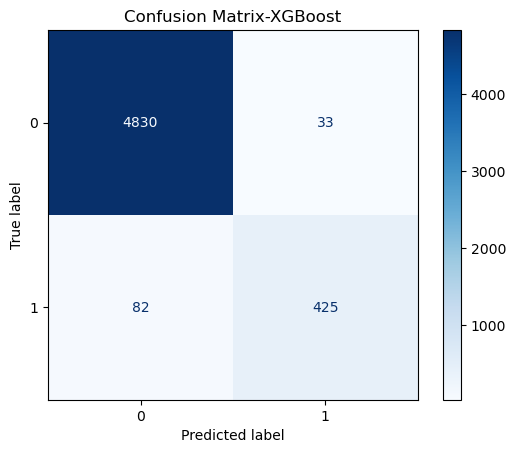

In [221]:
cm = confusion_matrix(y_test, ypredxg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix-XGBoost")
plt.show()

In [198]:
params = {'min_child_weight': [1, 5, 10],
        'gamma': [0.5, 1, 1.5, 2, 5, 10],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'max_depth': [3, 4, 5, 10]
         }
model=GridSearchCV(XGBClassifier(random_state=518), params, cv=4)
model.fit(x_train,y_train)
no_of_combinations = 1
for key, value in params.items():
    no_of_combinations *= len(value)
print("best params: ", model.best_params_)
print("best score: ", model.best_score_)

best params:  {'colsample_bytree': 0.8, 'gamma': 0.5, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.6}
best score:  0.9812420178799489


In [263]:
modelxg=xgb.XGBClassifier(objective='binary:logistic', colsample_bytree=0.8, gamma=0.5, max_depth=3, min_child_weight=5, subsample=.06, random_state=518)

In [264]:
modelxg.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [265]:
ypredxg2=modelxg.predict(x_test)

In [266]:
print("XGBoost Classifier Model Accuracy:", accuracy_score(y_test, ypredxg2))

XGBoost Classifier Model Accuracy: 0.9780260707635009


In [267]:
print(precision_score(y_test, ypredxg2))

0.9200863930885529


In [268]:
print(recall_score(y_test, ypredxg2))

0.8402366863905325


In [400]:
print(roc_auc_score(y_test, ypredxg2))

0.9163141071269956


In [269]:
print(confusion_matrix(y_test, ypredxg2))

[[4826   37]
 [  81  426]]


In [227]:
print(classification_report(y_test, ypredxg2))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4863
           1       0.92      0.84      0.88       507

    accuracy                           0.98      5370
   macro avg       0.95      0.92      0.93      5370
weighted avg       0.98      0.98      0.98      5370



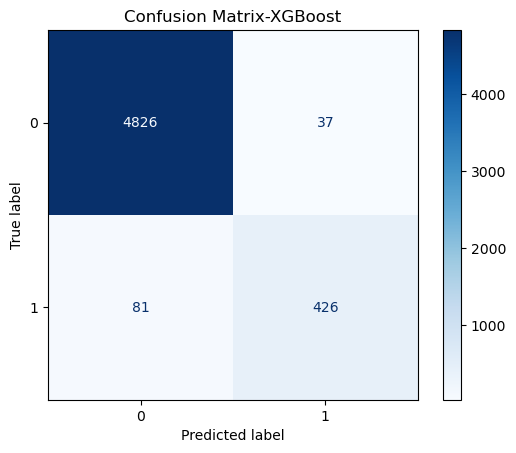

In [228]:
cm = confusion_matrix(y_test, ypredxg2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix-XGBoost")
plt.show()

In [257]:
knn = KNeighborsClassifier(n_neighbors=i)
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",19
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [258]:
ypredkn = knn.predict(x_test)

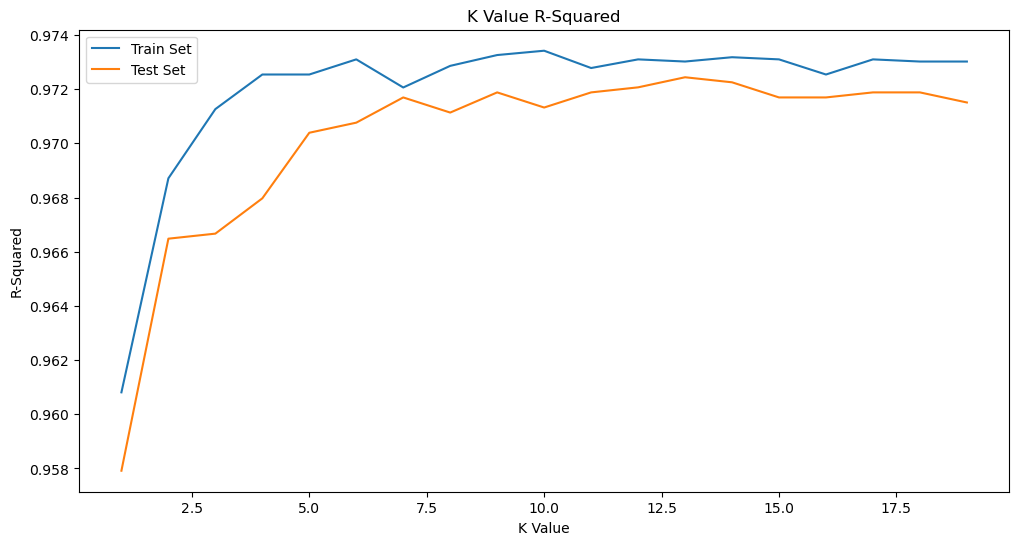

In [109]:
train_score = []
test_score = []
for i in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=i)
    train_score.append(cross_val_score(knn,x_train,y_train,cv=5).mean())
    knn.fit(x_train,y_train)
    test_score.append(knn.score(x_test, y_test))
plt.figure(figsize=(12, 6))
plt.plot(range(1, 20), train_score, markersize=10, label = "Train Set")
plt.plot(range(1, 20), test_score, markersize=10, label = "Test Set")
plt.title('K Value R-Squared')
plt.xlabel('K Value')
plt.ylabel('R-Squared')
plt.legend()
plt.show()

In [438]:
print(accuracy_score(y_test, ypredkn))

0.9715083798882681


In [439]:
print(precision_score(y_test, ypredkn))

0.9317073170731708


In [440]:
print(recall_score(y_test, ypredkn))

0.7534516765285996


In [441]:
print(roc_auc_score(y_test, ypredkn))

0.8738469569153382


In [442]:
print(confusion_matrix(y_test, ypredkn))

[[4835   28]
 [ 125  382]]


In [443]:
print(classification_report(y_test, ypredkn))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      4863
           1       0.93      0.75      0.83       507

    accuracy                           0.97      5370
   macro avg       0.95      0.87      0.91      5370
weighted avg       0.97      0.97      0.97      5370



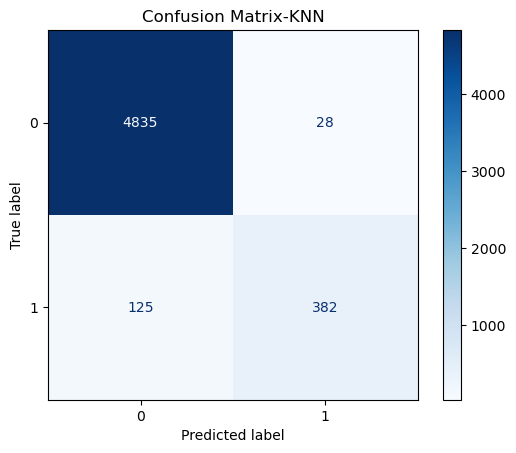

In [444]:
cm = confusion_matrix(y_test, ypredkn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix-KNN")
plt.show()

In [231]:
params = {'n_neighbors': [1, 2, 3, 5, 7, 9, 11, 15, 20],
          'weights': ['uniform', 'distance'],
          'metric': ['euclidean', 'manhattan']
         }
model=GridSearchCV(KNeighborsClassifier(), params, cv=4)
model.fit(x_train,y_train)
no_of_combinations = 1
for key, value in params.items():
    no_of_combinations *= len(value)
print("best params: ", model.best_params_)
print("best score: ", model.best_score_)

best params:  {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
best score:  0.9747765006385696


In [445]:
knn = KNeighborsClassifier(metric='manhattan',n_neighbors=9,weights='distance')
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",9
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [446]:
ypredkn2 = knn.predict(x_test)

In [447]:
print(accuracy_score(y_test, ypredkn2))

0.9726256983240223


In [448]:
print(precision_score(y_test, ypredkn2))

0.9245283018867925


In [449]:
print(recall_score(y_test, ypredkn2))

0.7731755424063116


In [450]:
print(roc_auc_score(y_test, ypredkn2))

0.8832976210900568


In [451]:
print(confusion_matrix(y_test, ypredkn2))

[[4831   32]
 [ 115  392]]


In [452]:
print(classification_report(y_test, ypredkn2))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4863
           1       0.92      0.77      0.84       507

    accuracy                           0.97      5370
   macro avg       0.95      0.88      0.91      5370
weighted avg       0.97      0.97      0.97      5370



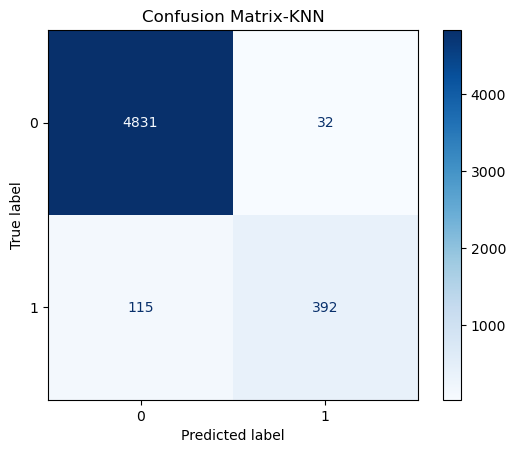

In [453]:
cm = confusion_matrix(y_test, ypredkn2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix-KNN")
plt.show()

In [244]:
knn = KNeighborsClassifier(metric='manhattan',n_neighbors=3,weights='distance')
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [245]:
ypredkn3 = knn.predict(x_test)

In [246]:
print(accuracy_score(y_test, ypredkn3))

0.9683426443202979


In [247]:
print(precision_score(y_test, ypredkn3))

0.8769574944071589


In [248]:
print(recall_score(y_test, ypredkn3))

0.7731755424063116


In [404]:
print(roc_auc_score(y_test, ypredkn3))

0.880932825696267


In [249]:
print(confusion_matrix(y_test, ypredkn3))

[[4808   55]
 [ 115  392]]


In [250]:
print(classification_report(y_test, ypredkn3))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4863
           1       0.88      0.77      0.82       507

    accuracy                           0.97      5370
   macro avg       0.93      0.88      0.90      5370
weighted avg       0.97      0.97      0.97      5370



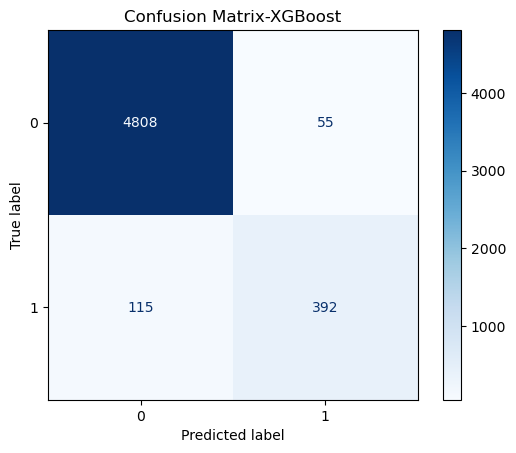

In [251]:
cm = confusion_matrix(y_test, ypredkn3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix-XGBoost")
plt.show()